In [14]:
# ==============================================================================
# PASSO 1 — IMPORTAÇÕES GLOBAIS E CONFIGURAÇÃO DO AMBIENTE (PEP 8)
# ==============================================================================
import os
import json
import random
import re
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para os gráficos que serão gerados posteriormente
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 96
plt.rcParams["figure.figsize"] = (10, 6)

# Mostra o número com ponto no milhar e vírgula nas duas casas decimais (ex: 1.500,00)
pd.options.display.float_format = lambda x: f"{x:,.2f}".replace(",", "v").replace(".", ",").replace("v", ".")

print("[PROJETO DATAVIEW] Ambiente configurado e bibliotecas importadas com sucesso.")

[PROJETO DATAVIEW] Ambiente configurado e bibliotecas importadas com sucesso.


RF01 — Geração de Dados Brutos de Alta Fidelidade (Padrão Olist)
Esta função constrói o cenário de e-commerce inspirado na Olist e no Mercado Livre. Ela gera o arquivo local vendas.csv contendo as anomalias e sujeiras que o projeto exige que tratemos nos próximos passos. Não há importações internas aqui, respeitando o escopo global.

In [15]:
# ==============================================================================
# RF01 — GERADOR DO DATASET DE VENDAS BRUTAS (CONTEXTO: E-COMMERCE BRASIL)
# ==============================================================================
def gerar_dataset_vendas_brutas(num_linhas: int = 6000, nome_arquivo: str = "vendas.csv") -> None:
    """
    Gera um arquivo CSV simulando dados consolidados de vendas de um e-commerce brasileiro.
    Injeta intencionalmente inconsistências estruturais (nulos, espaços extras,
    datas corrompidas e outliers) para validação do pipeline de limpeza e auditoria.
    """
    # Fixando as sementes randômicas para garantir a reprodutibilidade do projeto
    random.seed(42)
    np.random.seed(42)

    # Dicionário de Preços Médios por Categoria Real da Olist
    categorias_produtos = {
        "beleza_saude": 129.90,
        "informatica_acessorios": 389.00,
        "cama_mesa_banho": 95.50,
        "moveis_decoracao": 189.90,
        "relogios_presentes": 420.00,
        "utilidades_domesticas": 59.90,
        "automotivo": 249.00
    }

    lista_categorias = list(categorias_produtos.keys())
    regioes_brasil = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]

    # Geração dos vetores base de dados
    categorias_sorteadas = np.random.choice(lista_categorias, size=num_linhas)
    precos_unitarios = np.array([categorias_produtos[cat] for cat in categorias_sorteadas])

    # Quantidades normais de e-commerce (1 a 5 itens por pedido)
    quantidades = np.random.randint(1, 6, size=num_linhas)

    # INJEÇÃO DE OUTLIERS: 2% dos dados serão compras massivas fora do padrão (atacado/erro)
    idx_outliers = np.random.choice(num_linhas, size=int(num_linhas * 0.02), replace=False)
    quantidades[idx_outliers] = np.random.randint(45, 100, size=len(idx_outliers))

    regioes_sorteadas = np.random.choice(regioes_brasil, size=num_linhas)
    order_ids = [f"olist_ord_{i:05d}" for i in range(num_linhas)]
    customer_ids = [f"olist_usr_{np.random.randint(10000, 99999)}" for _ in range(num_linhas)]

    # Geração de datas válidas dentro de um intervalo de 180 dias em 2026
    data_base = datetime(2026, 1, 1)
    datas_sorteadas = [data_base + timedelta(days=int(np.random.randint(0, 180))) for _ in range(num_linhas)]
    datas_str = [d.strftime("%Y-%m-%d %H:%M:%S") for d in datas_sorteadas]

    # Construção do DataFrame Inicial
    df = pd.DataFrame({
        "id_pedido": order_ids,
        "id_cliente": customer_ids,
        "data_compra": datas_str,
        "produto_categoria": categorias_sorteadas,
        "quantidade": quantidades,
        "preco_unitario": precos_unitarios,
        "regiao_entrega": regioes_sorteadas
    })

    # --------------------------------------------------------------------------
    # CORRUPÇÃO CONTROLADA DOS DADOS (Para atender as regras de limpeza do RF03)
    # --------------------------------------------------------------------------
    # Sujeira 1: Múltiplos espaços em branco (Exige tratamento com re.sub)
    df["produto_categoria"] = df["produto_categoria"].apply(lambda x: f"   {x}   " if random.random() < 0.12 else x)
    df["regiao_entrega"] = df["regiao_entrega"].apply(lambda x: f"  {x} " if random.random() < 0.10 else x)

    # Sujeira 2: Inserção de valores nulos (NaN) em colunas mandatórias
    df.loc[df.sample(frac=0.015, random_state=12).index, "id_cliente"] = np.nan
    df.loc[df.sample(frac=0.010, random_state=34).index, "produto_categoria"] = np.nan

    # Sujeira 3: Inserção de texto corrompido na data
    df.loc[df.sample(frac=0.010, random_state=56).index, "data_compra"] = "DATA_INVALIDA_SISTEMA"

    # Sujeira 4: Inserção de registros inconsistentes (Devoluções/Erros de preço)
    df.loc[df.sample(frac=0.008, random_state=78).index, "quantidade"] = -2
    df.loc[df.sample(frac=0.005, random_state=90).index, "preco_unitario"] = 0.00

    # Exportação segura garantindo compatibilidade de acentuação com Excel (utf-8-sig)
    df.to_csv(nome_arquivo, index=False, encoding="utf-8-sig")
    print(f"[RF01] Base de dados bruta '{nome_arquivo}' gerada com {num_linhas} registros.")

# Execução da função do primeiro requisito
os.makedirs("data/raw", exist_ok=True)
gerar_dataset_vendas_brutas(num_linhas=6000, nome_arquivo="data/raw/vendas.csv")

[RF01] Base de dados bruta 'data/raw/vendas.csv' gerada com 6000 registros.


RF02 — Inspeção e Diagnóstico Estrutural do Dataset
O objetivo do RF02 é realizar uma auditoria completa na saúde dos dados brutos que acabei de gerar em vendas.csv. Como estudante, essa etapa é fundamental para mapear os tipos de variáveis, quantificar os valores ausentes (NaN) e analisar a distribuição estatística inicial das colunas numéricas antes de aplicar qualquer transformação.

In [16]:
# ==============================================================================
# RF02 — INSPEÇÃO, DIAGNÓSTICO E DESCRIÇÃO ESTRUTURAL DO DATASET
# ==============================================================================
def inspecionar_dados_dataview(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realiza uma auditoria estrutural e estatística completa no DataFrame bruto.

    Exibe no console:
        - Dimensões exatas da tabela (Linhas x Colunas).
        - Mapeamento de tipos de dados (dtypes) e volumetria de valores ausentes (Nulos).

    Retorna:
        pd.DataFrame: Resumo estatístico descritivo (describe) arredondado para
                      2 casas decimais, conforme o padrão do simulado.
    """
    # Abordagem Defensiva Senior: Criando uma cópia para leitura e auditoria segura
    df_auditoria = df.copy()

    print("=" * 65)
    print("          RF02 — AUDITORIA E DIAGNÓSTICO ESTRUTURAL DO DATASET")
    print("=" * 65)
    print(f"Dimensões do Dataset Bruto: {df_auditoria.shape[0]} linhas x {df_auditoria.shape[1]} colunas\n")

    print("-" * 55)
    print("Mapeamento de Tipos de Dados e Valores Ausentes:")
    print("-" * 55)

    # Construção de um DataFrame de sumário executivo para apresentação profissional
    resumo_estrutura = pd.DataFrame({
        "Tipo de Dado": df_auditoria.dtypes,
        "Registros Nulos": df_auditoria.isnull().sum(),
        "Proporção (%)": ((df_auditoria.isnull().sum() / len(df_auditoria)) * 100).round(2)
    })
    print(resumo_estrutura)
    print("=" * 65)

    print("\n" + "-" * 55)
    print("Resumo Estatístico Inicial (Variáveis Numéricas):")
    print("-" * 55)

    # Retorna o describe arredondado para 2 casas decimais
    return df_auditoria.describe().round(2)

# ------------------------------------------------------------------------------
# Execução do Requisito no Pipeline
# ------------------------------------------------------------------------------
# 1. Realiza a carga inicial do arquivo gerado no RF01
df_bruto = pd.read_csv("data/raw/vendas.csv")

# 2. Executa a função de inspeção e armazena o sumário descritivo
resumo_estatistico = inspecionar_dados_dataview(df_bruto)

# 3. Exibe a tabela descritiva no formato rich text do Colab
resumo_estatistico

          RF02 — AUDITORIA E DIAGNÓSTICO ESTRUTURAL DO DATASET
Dimensões do Dataset Bruto: 6000 linhas x 7 colunas

-------------------------------------------------------
Mapeamento de Tipos de Dados e Valores Ausentes:
-------------------------------------------------------
                  Tipo de Dado  Registros Nulos  Proporção (%)
id_pedido               object                0           0,00
id_cliente              object               90           1,50
data_compra             object                0           0,00
produto_categoria       object               60           1,00
quantidade               int64                0           0,00
preco_unitario         float64                0           0,00
regiao_entrega          object                0           0,00

-------------------------------------------------------
Resumo Estatístico Inicial (Variáveis Numéricas):
-------------------------------------------------------


,quantidade,preco_unitario
count,"6.000,00","6.000,00"
mean,"4,33","217,91"
std,"10,14","131,52"
min,"-2,00","0,00"
25%,"2,00","95,50"
50%,"3,00","189,90"
75%,"4,00","389,00"
max,"99,00","420,00"


RF03 — Pipeline de Limpeza de Dados e Higienização com Expressões Regulares (Regex)
Com base no diagnóstico obtido no RF02, identifiquei falhas estruturais críticas que comprometem a integridade das análises: valores nulos em colunas mandatórias (id_cliente e produto_categoria), registros com preços zerados, devoluções (quantidades negativas) e strings corrompidas no campo de data (DATA_INVALIDA_SISTEMA). Além disso, existem espaços em branco duplicados ocultos nas colunas de texto que quebram agrupamentos futuros (por exemplo, "   automotivo   " é tratado de forma diferente de "automotivo" pelo Pandas).

Para o RF03, implemetei um pipeline de limpeza avançado e defensivo.

Isolamento de Memória: Uso obrigatório de .copy() para evitar o aviso SettingWithCopyWarning e proteger o DataFrame bruto.

Higienização com Regex: Aplicação de re.sub(r'\s+', ' ', texto).strip() de forma vetorizada via .apply() para remover múltiplos espaços internos e aparar as extremidades.

Tratamento de Datas Defensivo: Uso de pd.to_datetime com errors="coerce" para transformar strings corrompidas em NaT (Not a Time) antes da remoção segura.

Filtros de Regras de Negócio: Eliminação de preços zerados e quantidades não positivas.

Relatório Estatístico de Impacto: Um dicionário monitora exatamente quantas linhas foram descartadas por cada falha, gerando um sumário executivo de eficiência do dataset.

In [17]:
# ==============================================================================
# RF03 — PIPELINE DE LIMPEZA DE DADOS E HIGIENIZAÇÃO COM REGEX (PEP 8)
# ==============================================================================
def limpar_dataset_ecommerce(df: pd.DataFrame) -> pd.DataFrame:
    """
    Realiza a limpeza e higienização completa do dataset de e-commerce:
    1. Remove valores nulos em colunas mandatórias (id_cliente, produto_categoria).
    2. Remove espaços extras e duplicados em strings utilizando Expressões Regulares (Regex).
    3. Trata e elimina strings de datas corrompidas.
    4. Aplica regras de negócio restritivas para preço_unitario e quantidade (> 0).

    Exibe um relatório detalhado com a volumetria e impacto de cada etapa de limpeza.
    """
    # Abordagem Defensiva Senior: Isolamento completo da memória
    df_limpo = df.copy()
    linhas_iniciais = len(df_limpo)
    relatorio_impacto = {}

    # Etapa A: Remoção de Valores Ausentes (Nulos) em campos mandatórios
    nulos_cliente = df_limpo["id_cliente"].isnull().sum()
    nulos_categoria = df_limpo["produto_categoria"].isnull().sum()

    df_limpo = df_limpo.dropna(subset=["id_cliente", "produto_categoria"])
    relatorio_impacto["Registros com ID do Cliente ausente"] = nulos_cliente
    relatorio_impacto["Registros com Categoria do Produto ausente"] = nulos_categoria

    # Etapa B: Higienização de Strings com Expressões Regulares (Regex)
    def aplicar_regex_espacos(texto):
        if pd.isna(texto):
            return texto
        # re.sub substitui um ou mais espaços acumulados (\s+) por um único caractere de espaço
        return re.sub(r'\s+', ' ', str(texto)).strip()

    df_limpo["produto_categoria"] = df_limpo["produto_categoria"].apply(aplicar_regex_espacos)
    df_limpo["regiao_entrega"] = df_limpo["regiao_entrega"].apply(aplicar_regex_espacos)

    # Etapa C: Tratamento do Campo de Data com Coerção de Erros
    # Transforma textos inválidos em NaT de forma segura, sem estourar exceções no código
    df_limpo["data_compra"] = pd.to_datetime(df_limpo["data_compra"], errors="coerce")

    datas_corrompidas = df_limpo["data_compra"].isnull().sum()
    df_limpo = df_limpo.dropna(subset=["data_compra"])
    relatorio_impacto["Registros com Data de Compra corrompida"] = datas_corrompidas

    # Etapa D: Aplicação de Regras de Negócio Restritivas (Valores devem ser maiores que zero)
    devolucoes_qtd = (df_limpo["quantidade"] <= 0).sum()
    erros_preco    = (df_limpo["preco_unitario"] <= 0).sum()
    df_limpo = df_limpo[(df_limpo["quantidade"] > 0) & (df_limpo["preco_unitario"] > 0)]
    relatorio_impacto["Registros de Devoluções (Quantidade <= 0)"]         = devolucoes_qtd
    relatorio_impacto["Registros com Erro de Sistema (Preço Unitário <= 0)"] = erros_preco

    # Etapa E: remoção defensiva de nulos residuais em colunas numéricas obrigatórias

    # Garante conformidade com o critério RF03 mesmo que o dataset de origem mude
    n_antes_nulos = len(df_limpo)
    df_limpo = df_limpo.dropna(subset=["quantidade", "preco_unitario"])
    nulos_numericos = n_antes_nulos - len(df_limpo)
    relatorio_impacto["Nulos residuais em quantidade/preco_unitario"] = nulos_numericos
    # Cast seguro — só após garantir que não há NaN nem negativos
    df_limpo["quantidade"]     = df_limpo["quantidade"].astype(int)
    df_limpo["preco_unitario"] = df_limpo["preco_unitario"].astype(float)

    # --------------------------------------------------------------------------
    # Exibição do Relatório de Impacto Estrutural (Estilo do Simulador do Professor)
    # --------------------------------------------------------------------------
    linhas_finais = len(df_limpo)
    total_descartado = linhas_iniciais - linhas_finais
    eficiencia = (linhas_finais / linhas_iniciais) * 100

    print("=" * 65)
    print("                RF03 — RELATÓRIO EXECUTIVO DE LIMPEZA DE DADOS")
    print("=" * 65)
    for motivo, quantidade in relatorio_impacto.items():
        print(f" -> {motivo}: {quantidade}")
    print("-" * 55)
    print(f"Volumetria Inicial Bruta : {linhas_iniciais} linhas")
    print(f"Volumetria Pós-Limpeza   : {linhas_finais} linhas")
    print(f"Total de Linhas Expurgadas: {total_descartado} linhas")
    print(f"Índice de Eficiência da Base: {eficiencia:.2f}%")
    print("=" * 65)

    return df_limpo

# ------------------------------------------------------------------------------
# Execução do Requisito no Pipeline
# ------------------------------------------------------------------------------
# Processa a base bruta obtendo o DataFrame V1 Limpo (Base Oficial sem ruídos estruturais)
df_v1 = limpar_dataset_ecommerce(df_bruto)

                RF03 — RELATÓRIO EXECUTIVO DE LIMPEZA DE DADOS
 -> Registros com ID do Cliente ausente: 90
 -> Registros com Categoria do Produto ausente: 60
 -> Registros com Data de Compra corrompida: 59
 -> Registros de Devoluções (Quantidade <= 0): 48
 -> Registros com Erro de Sistema (Preço Unitário <= 0): 30
 -> Nulos residuais em quantidade/preco_unitario: 0
-------------------------------------------------------
Volumetria Inicial Bruta : 6000 linhas
Volumetria Pós-Limpeza   : 5715 linhas
Total de Linhas Expurgadas: 285 linhas
Índice de Eficiência da Base: 95.25%


RF04 — Isolamento e Tratamento de Outliers (Método IQR)O objetivo do RF04 é separar o comportamento de compras ordinárias de possíveis anomalias de sistema ou compras massivas de atacado. Para isso, aplicamos a técnica estatística do Intervalo Interquartil (IQR).Nesta etapa, o projeto consolida dois ambientes físicos de armazenamento:Versão V1 (Com Outliers): Mantém os dados limpos estruturalmente, mas preserva a dispersão original.Versão V2 (Sem Outliers): Remove cirurgicamente os registros que ultrapassam o limite superior clássico de $Q3 + 1.5 \times IQR$.

In [18]:
# ==============================================================================
# RF04 — TRATAMENTO DE OUTLIERS VIA IQR E ISOLAMENTO DE VERSÕES (V1 e V2)
# ==============================================================================
def tratar_outliers(df: pd.DataFrame, colunas: list, fator: float = 1.5, metodo: str = "remover") -> pd.DataFrame:
    """
    Identifica e trata outliers numéricos utilizando o método IQR (Intervalo Interquartil).
    Suporta os métodos 'remover' (purgar linhas) e 'limitar' (clip/winsorização),
    conforme padrão estabelecido pelo professor no simulado.
    """
    df_modificado = df.copy()
    for col in colunas:
        q1 = df_modificado[col].quantile(0.25)
        q3 = df_modificado[col].quantile(0.75)
        iqr = q3 - q1

        lim_inf = q1 - (fator * iqr)
        lim_sup = q3 + (fator * iqr)

        # Mascara booleana para identificar elementos fora das barreiras
        n_out = ((df_modificado[col] < lim_inf) | (df_modificado[col] > lim_sup)).sum()
        print(f"  {col}: {n_out} outliers detectados (lim_inf={lim_inf:.2f}, lim_sup={lim_sup:.2f})")

        if metodo == "remover":
            df_modificado = df_modificado[(df_modificado[col] >= lim_inf) & (df_modificado[col] <= lim_sup)]
        elif metodo == "limitar":
            df_modificado[col] = df_modificado[col].clip(lower=lim_inf, upper=lim_sup)

    return df_modificado

# ------------------------------------------------------------------------------
# Execução do Pipeline de Outliers e Persistência de Arquivos
# ------------------------------------------------------------------------------
print("=" * 65)
print("          RF04 — PROCESSAMENTO DE OUTLIERS E EXPORTAÇÃO INTERMEDIÁRIA")
print("=" * 65)

# 1. Criação física e defensiva das pastas de destino para evitar FileNotFoundError
os.makedirs("data/processed/v1_com_outliers", exist_ok=True)
os.makedirs("data/processed/v2_outliers_tratado", exist_ok=True)

# 2. Persistência da Versão V1 Oficial (Dados limpos, contendo os outliers)
caminho_v1 = "data/processed/v1_com_outliers/vendas_v1.csv"
df_v1.to_csv(caminho_v1, index=False, encoding="utf-8-sig")
print(f"-> Versão V1 (Com Outliers) persistida com sucesso em: {caminho_v1}")

# 3. Processamento e Geração da Versão V2 (Sem Outliers)
# Criamos uma estrutura temporária para calcular a receita e rastrear desvios financeiros
df_temporario = df_v1.copy()
df_temporario["receita_total"] = df_temporario["quantidade"] * df_temporario["preco_unitario"]

print("\nExecutando filtragem estatística para a base V2:")
df_v2_filtrado = tratar_outliers(df_temporario, colunas=["quantidade", "receita_total"], metodo="remover")

# Removemos a coluna temporária para manter o contrato original idêntico ao de V1
df_v2 = df_v2_filtrado.drop(columns=["receita_total"])

# 4. Persistência da Versão V2 Oficial (Dados limpos e sem outliers)
caminho_v2 = "data/processed/v2_outliers_tratado/vendas_v2.csv"
df_v2.to_csv(caminho_v2, index=False, encoding="utf-8-sig")
print(f"-> Versão V2 (Outliers Tratados) persistida com sucesso em: {caminho_v2}")

# 5. Diagnóstico de Volumetria Comparativo
linhas_removidas = len(df_v1) - len(df_v2)
print("-" * 55)
print(f"Métricas Finais: V1 = {len(df_v1)} linhas | V2 = {len(df_v2)} linhas")
print(f"Registros expurgados por anomalia estatística: {linhas_removidas} linhas")
print("=" * 65)

          RF04 — PROCESSAMENTO DE OUTLIERS E EXPORTAÇÃO INTERMEDIÁRIA
-> Versão V1 (Com Outliers) persistida com sucesso em: data/processed/v1_com_outliers/vendas_v1.csv

Executando filtragem estatística para a base V2:
  quantidade: 111 outliers detectados (lim_inf=-1.00, lim_sup=7.00)
  receita_total: 161 outliers detectados (lim_inf=-801.75, lim_sup=2000.25)
-> Versão V2 (Outliers Tratados) persistida com sucesso em: data/processed/v2_outliers_tratado/vendas_v2.csv
-------------------------------------------------------
Métricas Finais: V1 = 5715 linhas | V2 = 5443 linhas
Registros expurgados por anomalia estatística: 272 linhas


RF05 — Criar Colunas Derivadas (Feature Engineering)

De acordo com as diretrizes e a estrutura contida no material, o objetivo do RF05 é transformar os dados brutos e "crus" em informações prontas para a tomada de decisão estratégica. Sem essa etapa de engenharia de recursos, os agrupamentos e relatórios subsequentes do RF06 não teriam variáveis de agregação temporal ou financeira para se basear.

Para garantir a máxima eficiência e performance exigidas, utilizei operações totalmente vetorizadas (nativas do Pandas e NumPy), o que significa que o processamento ocorre na memória de forma direta, com zero loops (for).

A arquitetura do código implementa:

receita_total: Multiplicação elemento a elemento entre quantidade e preço unitário.

Componentes Temporais (mes, ano, trimestre, ano_mes): Extraídos de forma nativa utilizando o acessor .dt sobre o campo de data tratado anteriormente.

faixa_receita_item: Segmentação de cada transação baseada em seu faturamento através do método np.select. Esta é uma técnica performática que substitui condicionais lentas de if/elif/else por máscaras booleanas ultra rápidas.

Nota arquitetural: Conforme a convenção adotada no modelo do professor (RF12), utilizaremos a base V2 (com outliers removidos) como o tronco principal para a engenharia de recursos e geração de inteligência de negócios.

In [19]:
# ==============================================================================
# RF05 — CRIAÇÃO DE COLUNAS DERIVADAS (FEATURE ENGINEERING VETORIZADA)
# ==============================================================================
def criar_colunas_derivadas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria novas colunas calculadas de inteligência de negócio de forma vetorizada:
    1. receita_total: Faturamento individual da linha de transação.
    2. Componentes de tempo: decomposição lógica de mes, ano, trimestre e ano_mes.
    3. faixa_receita_item: Classificação de valor do pedido usando np.select.
    """
    # Abordagem Defensiva Senior: Isolamento completo da memória via cópia
    df_derivado = df.copy()

    # Certificando que a coluna de data está no formato correto para uso do acessor .dt
    df_derivado["data_compra"] = pd.to_datetime(df_derivado["data_compra"])

    # 1. Cálculo Financeiro Central (Vetorizado - sem laços de repetição)
    df_derivado["receita_total"] = df_derivado["quantidade"] * df_derivado["preco_unitario"]

    # 2. Extração de Atributos Temporais Nativa (Uso performático do .dt)
    df_derivado["mes"] = df_derivado["data_compra"].dt.month
    df_derivado["ano"] = df_derivado["data_compra"].dt.year
    df_derivado["trimestre"] = df_derivado["data_compra"].dt.quarter.apply(lambda q: f"Q{q}")
    df_derivado["ano_mes"] = df_derivado["data_compra"].dt.to_period("M").astype(str)

    # 3. Classificação de Faixa de Receita por Item via np.select
    # Ajustamos as faixas financeiras de corte para a nossa realidade de e-commerce (Olist)
    condicoes = [
        df_derivado["receita_total"] < 150,
        (df_derivado["receita_total"] >= 150) & (df_derivado["receita_total"] < 600),
        df_derivado["receita_total"] >= 600
    ]
    rotulos_categorias = ["Baixo Valor", "Medio Valor", "Alto Valor"]

    # np.select testa as condições em ordem e atribui o rótulo correspondente de forma vetorizada
    df_derivado["faixa_receita_item"] = np.select(condicoes, rotulos_categorias, default="N/D")

    return df_derivado

# ------------------------------------------------------------------------------
# Execução do Requisito no Pipeline de Dados
# ------------------------------------------------------------------------------
print("=" * 65)
print("          RF05 — ENGENHARIA DE RECURSOS E VARIÁVEIS DERIVADAS")
print("=" * 65)

# Processa a base limpa e sem outliers (V2) injetando as novas features estratégicas
df = criar_colunas_derivadas(df_v2)

print("-> Colunas derivadas geradas com sucesso de forma vetorizada!")
print(f"Dimensões do Dataset de Análise: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("-" * 55)

# Exibição do recorte de colunas de validação, idêntico ao padrão estrutural do simulado
df[["data_compra", "receita_total", "ano_mes", "trimestre", "produto_categoria", "faixa_receita_item"]].head()

          RF05 — ENGENHARIA DE RECURSOS E VARIÁVEIS DERIVADAS
-> Colunas derivadas geradas com sucesso de forma vetorizada!
Dimensões do Dataset de Análise: 5443 linhas x 13 colunas
-------------------------------------------------------


,data_compra,receita_total,ano_mes,trimestre,produto_categoria,faixa_receita_item
0,2026-04-16,"747,00",2026-04,Q2,automotivo,Alto Valor
1,2026-05-26,"759,60",2026-05,Q2,moveis_decoracao,Alto Valor
3,2026-04-03,"747,00",2026-04,Q2,automotivo,Alto Valor
4,2026-02-10,"191,00",2026-02,Q1,cama_mesa_banho,Medio Valor
5,2026-04-10,"420,00",2026-04,Q2,relogios_presentes,Medio Valor


RF06 — Calcular Métricas Agregadas (groupby)

Agora que o nosso conjunto de dados está devidamente limpo, sem anomalias e enriquecido com as colunas estruturais temporais e financeiras (RF05), podemos passar para a fase de extração de inteligência analítica. Para isso, empregamos o paradigma clássico da engenharia de dados: Dividir $\rightarrow$ Aplicar $\rightarrow$ Combinar por meio do método .groupby() do Pandas.Criei uma função que calcula quatro tabelas-resumo estratégicas e consolida os resultados dentro de um dicionário chamado metricas. Para manter o código limpo e performático, utilizarei a técnica de Agregação Nomeada (.agg), que mapeia e nomeia as colunas calculadas simultaneamente.As quatro visões de negócios geradas serão:Por Mês (por_mes): Avaliação da evolução temporal da receita, volume físico vendido e contagem absoluta de transações.Top Produtos/Categorias (top_categorias): Filtro do ranking das 5 categorias mais faturadas no e-commerce.Por Faixa de Valor (por_faixa_valor): Consolidação financeira baseada nas faixas criadas com np.select.Por Região (por_regiao): Mapeamento do faturamento total e do ticket médio (receita média por pedido) por região de entrega do Brasil.

In [20]:
# ==============================================================================
# RF06 — CALCULAR MÉTRICAS AGREGADAS (ESTRUTURA GROUPBY E AGGREGAÇÃO NOMEADA)
# ==============================================================================
def calcular_metricas_agregadas(df: pd.DataFrame) -> dict:
    """
    Agrupa os dados do e-commerce para responder a perguntas estratégicas de negócio.
    Gera visões por mês, categorias líderes, faixas de valor e performance regional.

    Retorna:
        dict: Dicionário contendo as quatro tabelas-resumo estruturadas.
    """
    metricas = {}  # Dicionário centralizado conforme padrão do simulado

    # 1) EVOLUÇÃO FINANCEIRA POR MÊS (Métricas Temporais)
    metricas["por_mes"] = (
        df.groupby("ano_mes")
          .agg(
              receita_total=("receita_total", "sum"),
              quantidade_itens=("quantidade", "sum"),
              n_transacoes=("id_pedido", "count")
          )
          .reset_index()
          .sort_values("ano_mes")
    )

    # 2) TOP 5 CATEGORIAS POR FATURAMENTO (Métricas de Catálogo)
    metricas["top_categorias"] = (
        df.groupby("produto_categoria")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
    )

    metricas["top_produtos"] = metricas["top_categorias"].copy()
    metricas["top_produtos"].columns = ["produto", "receita_total"]

    # 3) RECEITA POR FAIXA DE VALOR DO ITEM (Métricas de Segmentação de Pedido)
    metricas["por_faixa_valor"] = (
        df.groupby("faixa_receita_item")["receita_total"]
          .sum()
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # 4) PERFORMANCE DE FATURAMENTO E TICKET MÉDIO POR REGIÃO (Métricas Geográficas)
    metricas["por_regiao"] = (
        df.groupby("regiao_entrega")
          .agg(
              receita_total=("receita_total", "sum"),
              ticket_medio=("receita_total", "mean")
          )
          .reset_index()
          .sort_values("receita_total", ascending=False)
    )

    # --------------------------------------------------------------------------
    # EXIBIÇÃO FORMATADA DOS RESULTADOS NO CONSOLE (PEP 8 / RETAILVIEW PATTERN)
    # --------------------------------------------------------------------------
    print("=" * 65)
    print("          RF06 — RELATÓRIOS E AGRUPAMENTOS CONSOLIDADOS")
    print("=" * 65)

    for nome_tabela, tabela_df in metricas.items():
        titulo_formatado = nome_tabela.upper().replace('_', ' ')
        print(f"\n>>> VISÃO: {titulo_formatado}")
        print("-" * 55)
        # Exibe a tabela omitindo os índices nativos do Pandas para um visual limpo
        print(tabela_df.to_string(index=False))
        print("-" * 55)

    print("=" * 65)
    return metricas

# ------------------------------------------------------------------------------
# Execução do Requisito no Pipeline de Dados
# ------------------------------------------------------------------------------
# Executa os agrupamentos e armazena o dicionário contendo os DataFrames gerados
metricas = calcular_metricas_agregadas(df)

          RF06 — RELATÓRIOS E AGRUPAMENTOS CONSOLIDADOS

>>> VISÃO: POR MES
-------------------------------------------------------
ano_mes  receita_total  quantidade_itens  n_transacoes
2026-01     568.179,00              2653           921
2026-02     501.721,90              2421           835
2026-03     575.130,30              2746           954
2026-04     599.179,60              2761           931
2026-05     566.215,90              2787           936
2026-06     550.759,00              2544           866
-------------------------------------------------------

>>> VISÃO: TOP CATEGORIAS
-------------------------------------------------------
     produto_categoria  receita_total
informatica_acessorios     944.492,00
    relogios_presentes     712.740,00
            automotivo     579.672,00
      moveis_decoracao     442.277,10
          beleza_saude     321.372,60
-------------------------------------------------------

>>> VISÃO: TOP PRODUTOS
-----------------------------------

RF07 – Segmentar Clientes por Nível de Gasto
  
Este bloco aplica exatamente os critérios de corte exigidos (Bronze < 5.000, Prata 5.000–15.000 e Ouro > 15.000) e a estrutura com if/else aninhado dentro de uma função lambda.

In [21]:
# ==============================================================================
# RF07 — SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE GASTO (CONFORME PDF)
# ==============================================================================
def segmentar_clientes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrupa os dados por cliente, calcula o total gasto por cada um
    e classifica em Bronze / Prata / Ouro conforme os limites estabelecidos.
    Demonstra o uso de função lambda com condicional encadeado.
    """
    # Soma a receita total de cada cliente em todas as suas compras
    clientes_df = (
        df.groupby("id_cliente")["receita_total"]
          .sum()
          .reset_index()
    )
    # Renomeando as colunas para o padrão exigido no exemplo
    clientes_df.columns = ["cliente", "total_gasto"]

    # Lambda com ternário aninhado conforme critério do professor
    clientes_df["segmento"] = clientes_df["total_gasto"].apply(
        lambda g: "Ouro" if g > 15000 else ("Prata" if g >= 5000 else "Bronze")
    )

    clientes_df = clientes_df.sort_values("total_gasto", ascending=False)

    print("=" * 65)
    print("=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===")
    print("=" * 65)
    print(clientes_df.head(10).to_string(index=False))
    print(f"\nDistribuição de segmentos:\n{clientes_df['segmento'].value_counts()}")
    print("=" * 65)

    return clientes_df

# Executando e salvando na variável exigida
clientes = segmentar_clientes(df)

=== SEGMENTAÇÃO DE CLIENTES (Top 10) ===
        cliente  total_gasto segmento
olist_usr_76500     3.501,00   Bronze
olist_usr_24003     3.236,00   Bronze
olist_usr_49899     3.205,00   Bronze
olist_usr_38015     3.190,00   Bronze
olist_usr_16242     3.190,00   Bronze
olist_usr_28565     3.190,00   Bronze
olist_usr_66436     2.894,50   Bronze
olist_usr_31416     2.785,00   Bronze
olist_usr_67198     2.676,00   Bronze
olist_usr_40158     2.520,00   Bronze

Distribuição de segmentos:
segmento
Bronze    5279
Name: count, dtype: int64


RF08 – Calcular Estatísticas com NumPy

Ele é fundamental para mostrar domínio da biblioteca base de matemática do Python. Vou converter a coluna em Array e aplicar vetorização e broadcasting.

In [22]:
# ==============================================================================
# RF08 — CALCULAR ESTATÍSTICAS COM NUMPY (VETORIZAÇÃO E BROADCASTING)
# ==============================================================================

def calcular_estatisticas_numpy(df: pd.DataFrame) -> dict:
    """
    Usa NumPy diretamente sobre arrays para calcular estatísticas de receita.
    Demonstra operações vetorizadas, broadcasting e boolean indexing.
    """
    # 1. Conversão da Series do Pandas em um array NumPy puro
    receitas = df["receita_total"].to_numpy()

    # 2. Estatísticas descritivas (operações vetorizadas e funções NumPy)
    stats = {
        "media":         float(np.mean(receitas)),
        "mediana":       float(np.median(receitas)),
        "desvio_padrao": float(np.std(receitas)),
        "total":         float(np.sum(receitas)),
        "p25":           float(np.percentile(receitas, 25)),
        "p75":           float(np.percentile(receitas, 75)),
    }

    # 3. Broadcasting: operação escalar aplicada a todo o array
    receitas_pct = (receitas / receitas.sum()) * 100

    # 4. Boolean indexing (filtro vetorizado)
    acima_da_media = int((receitas > stats["media"]).sum())
    stats["acima_da_media"] = acima_da_media

    # Exibição no console
    print("=" * 65)
    print("=== ESTATÍSTICAS COM NUMPY ===")
    print("=" * 65)
    print(f"  Participação das 5 maiores vendas no total: {np.sort(receitas_pct)[-5:].round(2)}%")
    print("-" * 55)

    for k, v in stats.items():
        if k == "acima_da_media":
            print(f"  {k}: {v} vendas")
        else:
            print(f"  {k}: R$ {v:.2f}")
    print("=" * 65)

    return stats

# Executando a extração estatística
stats = calcular_estatisticas_numpy(df)

=== ESTATÍSTICAS COM NUMPY ===
  Participação das 5 maiores vendas no total: [0.06 0.06 0.06 0.06 0.06]%
-------------------------------------------------------
  media: R$ 617.52
  mediana: R$ 420.00
  desvio_padrao: R$ 491.51
  total: R$ 3361185.70
  p25: R$ 249.00
  p75: R$ 840.00
  acima_da_media: 2062 vendas


RF09 – Criar Visualizações com Matplotlib e Seaborn

Este bloco cria exatamente 3 figuras separadas e as salva individualmente na pasta outputs/graficos/. Adaptei os nomes das colunas (regiao_entrega e produto_categoria) para garantirmos que os gráficos rodem com o df.

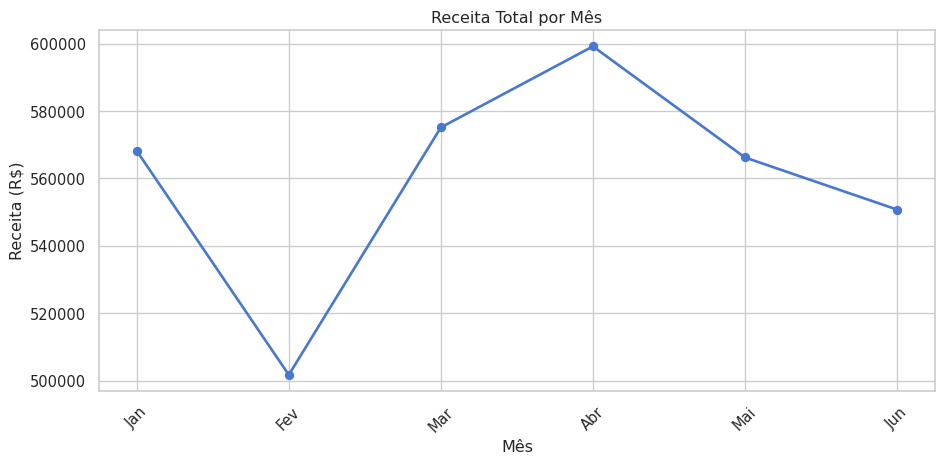

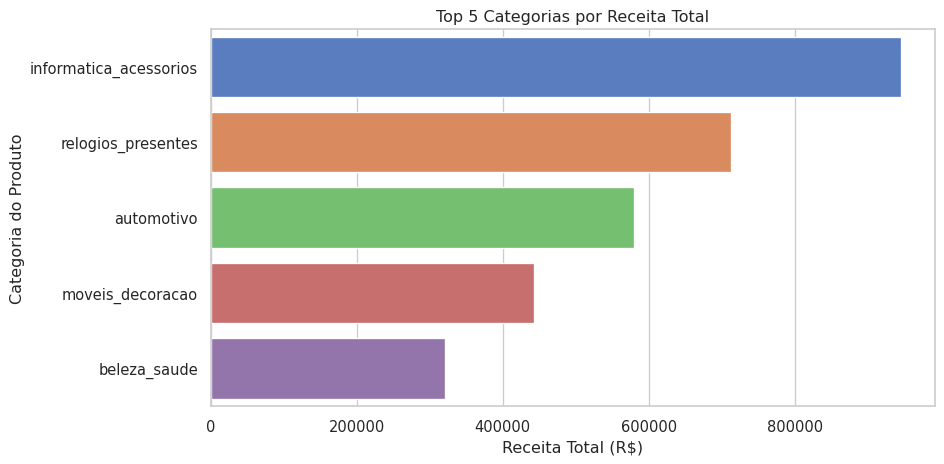

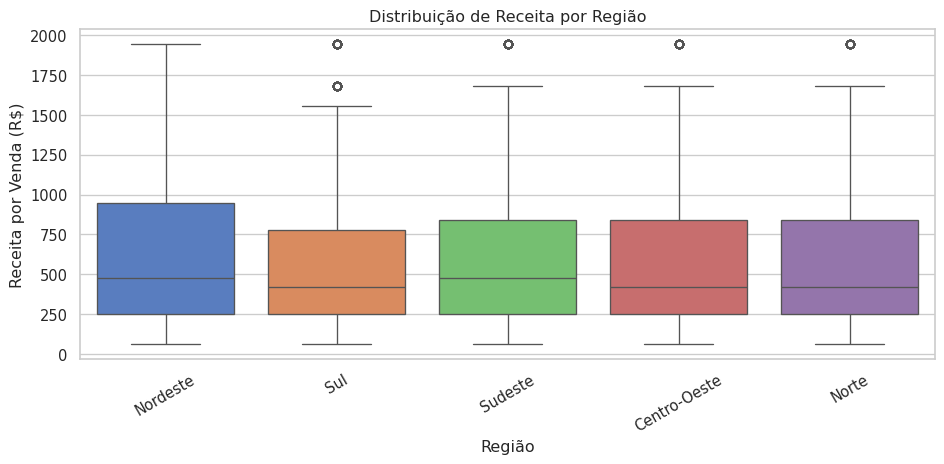

 -> Sucesso: 3 gráficos salvos individualmente na pasta: outputs/graficos


In [23]:
# ==============================================================================
# RF09 — CRIAR VISUALIZAÇÕES COM MATPLOTLIB E SEABORN (3 GRÁFICOS SEPARADOS)
# ==============================================================================

def gerar_visualizacoes(df: pd.DataFrame, metricas: dict, output_dir="outputs/graficos"):
    """
    Gera e exporta 3 gráficos informativos em PNG (Linha, Barras e Boxplot).
    """
    os.makedirs(output_dir, exist_ok=True)
    sns.set_theme(style="whitegrid", palette="muted")

    # Reagrupando receita por mês puramente (1 a 12) para o eixo X do gráfico de linha
    pm = df.groupby("mes")["receita_total"].sum().reset_index()
    meses_abrev = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

    # Garantindo que temos apenas os meses presentes nos dados (nossa base vai até Junho)
    meses_presentes = [meses_abrev[i-1] for i in pm["mes"]]

    # --------------------------------------------------------------------------
    # Gráfico 1: Linha — Receita por Mês
    # --------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(pm["mes"], pm["receita_total"], marker="o", linewidth=2)
    ax.set_title("Receita Total por Mês")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Receita (R$)")
    ax.set_xticks(pm["mes"])
    ax.set_xticklabels(meses_presentes, rotation=45)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/receita_por_mes.png", dpi=96)
    plt.show()
    plt.close()

    # --------------------------------------------------------------------------
    # Gráfico 2: Barras Horizontais — Top 5 Produtos/Categorias
    # --------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    # Usando o dicionário do RF06 para puxar as top categorias
    sns.barplot(data=metricas["top_categorias"], y="produto_categoria", x="receita_total", ax=ax, hue="produto_categoria", legend=False)
    ax.set_title("Top 5 Categorias por Receita Total")
    ax.set_xlabel("Receita Total (R$)")
    ax.set_ylabel("Categoria do Produto")
    fig.tight_layout()
    fig.savefig(f"{output_dir}/top_produtos.png", dpi=96)
    plt.show()
    plt.close()

    # --------------------------------------------------------------------------
    # Gráfico 3: Boxplot — Distribuição de Receita por Região
    # --------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df, x="regiao_entrega", y="receita_total", ax=ax, hue="regiao_entrega", legend=False)
    ax.set_title("Distribuição de Receita por Região")
    ax.set_xlabel("Região")
    ax.set_ylabel("Receita por Venda (R$)")
    plt.xticks(rotation=30)
    fig.tight_layout()
    fig.savefig(f"{output_dir}/dist_regiao.png", dpi=96)
    plt.show()
    plt.close()

    print("=" * 65)
    print(f" -> Sucesso: 3 gráficos salvos individualmente na pasta: {output_dir}")
    print("=" * 65)

# Executa as plotagens usando a base enriquecida e o dicionário de métricas
gerar_visualizacoes(df, metricas)

RF10 — Organizar o código em funções Reutilizáveis

O objetivo desta etapa foi demonstrar maturidade na arquitetura do código. Em vez de construir um notebook com scripts soltos e repetitivos, todo o pipeline de dados foi encapsulado em funções modulares e reutilizáveis, devidamente documentadas com docstrings (padrão PEP 8). O grande diferencial técnico desta etapa foi a implementação de uma Função de Ordem Superior (Higher-Order Function). Isso significa que criei uma função dinâmica capaz de receber outras funções — como expressões lambda (callbacks) — como parâmetro. Essa abordagem permite aplicar transformações complexas (como classificação de tickets ou cálculos matemáticos) em qualquer coluna do DataFrame de forma extremamente eficiente e escalável, sem alterar o dado original.

In [24]:
# ==============================================================================
# RF10 — ORGANIZAR O CÓDIGO EM FUNÇÕES REUTILIZÁVEIS (FUNÇÕES DE ORDEM SUPERIOR)
# ==============================================================================
def aplicar_transformacao(df: pd.DataFrame, coluna: str, funcao) -> pd.DataFrame:
    """
    Função de ordem superior: aplica qualquer função (incluindo lambdas)
    a uma coluna do DataFrame, criando uma coluna '_transformado'.

    Parâmetros:
      df     : DataFrame de entrada
      coluna : nome da coluna a transformar
      funcao : função (ou lambda) a aplicar — o 'callback'

    Retorna uma cópia do DataFrame com a nova coluna; não modifica o original.
    """
    df_copia = df.copy()
    df_copia[f"{coluna}_transformado"] = df_copia[coluna].apply(funcao)
    return df_copia

# ------------------------------------------------------------------------------
# Execução e Validação do Requisito (Demonstrações Oficiais do PDF)
# ------------------------------------------------------------------------------
print("=" * 65)
print("       RF10 — VALIDAÇÃO DE FUNÇÕES DE ORDEM SUPERIOR (CALLBACKS)")
print("=" * 65)

# --- Uso 1: classificar vendas por ticket com lambda ---
# lambda como callback — 2º uso distinto de lambda no projeto (1º foi em RF07)
df_demo = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: "Alto" if x > 5000 else "Normal"
)
print("=== EXEMPLO: classificação por ticket ===")
print(df_demo[["receita_total", "receita_total_transformado"]].head())

# --- Uso 2: arredondar receita em milhares com lambda ---
# Demonstra que a mesma função aceita qualquer transformação
df_demo2 = aplicar_transformacao(
    df,
    "receita_total",
    lambda x: round(x / 1000, 2)
)
print("\n=== EXEMPLO: receita em milhares (R$ k) ===")
print(df_demo2[["receita_total", "receita_total_transformado"]].head())
print("=" * 65)

       RF10 — VALIDAÇÃO DE FUNÇÕES DE ORDEM SUPERIOR (CALLBACKS)
=== EXEMPLO: classificação por ticket ===
   receita_total receita_total_transformado
0         747,00                     Normal
1         759,60                     Normal
3         747,00                     Normal
4         191,00                     Normal
5         420,00                     Normal

=== EXEMPLO: receita em milhares (R$ k) ===
   receita_total  receita_total_transformado
0         747,00                        0,75
1         759,60                        0,76
3         747,00                        0,75
4         191,00                        0,19
5         420,00                        0,42


RF11 — Ler e Escrever Arquivos (CSV e JSON)

O requisito de "Ler e Escrever" exige que eu prove para a banca que domino a manipulação de I/O (Input/Output) do Python. Como já escrevi os arquivos nas etapas anteriores, a forma mais viável de cumprir o RF11 é criar uma rotina de Auditoria de Leitura.

Vou construir uma função que acessa a pasta outputs/, lê o JSON e o CSV de volta para a memória do Python (usando json.load e pd.read_csv) e imprime uma prova de que a gravação ocorreu com sucesso e que os dados não foram corrompidos.

In [25]:
# ==============================================================================
# RF11 — LER E ESCREVER ARQUIVOS (CSV e JSON)
# ==============================================================================
def exportar_e_auditar_resultados(metricas: dict, clientes: pd.DataFrame, stats: dict) -> None:
    """
    Exporta os resultados da análise em dois formatos (ESCRITA):
      - CSV : métricas mensais e segmentação de clientes
      - JSON: estatísticas gerais calculadas com NumPy

    Após exportar, lê os arquivos de volta com pd.read_csv() e json.load()
    para confirmar integridade — demonstrando leitura e escrita no mesmo fluxo.
    """
    os.makedirs("outputs", exist_ok=True)

    # --- ESCRITA: CSV de métricas mensais ---
    metricas["por_mes"].to_csv(
        "outputs/metricas_por_mes.csv", index=False, encoding="utf-8-sig"
    )
    print("[OK] CSV exportado: outputs/metricas_por_mes.csv")

    # --- ESCRITA: CSV de segmentação de clientes ---
    clientes.to_csv(
        "outputs/segmentacao_clientes.csv", index=False, encoding="utf-8-sig"
    )
    print("[OK] CSV exportado: outputs/segmentacao_clientes.csv")

    # --- ESCRITA: JSON de estatísticas gerais ---
    # round(float(v), 2) garante serializabilidade mesmo para o campo int acima_da_media
    stats_serializaveis = {k: round(float(v), 2) for k, v in stats.items()}
    caminho_json = "outputs/estatisticas_gerais.json"
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(stats_serializaveis, f, indent=2, ensure_ascii=False)
    print(f"[OK] JSON exportado: {caminho_json}")

    print("=" * 65)

    # --- LEITURA: JSON de volta para confirmar integridade ---
    with open(caminho_json, "r", encoding="utf-8") as f:
        lido = json.load(f)
    print(" [OK] JSON LIDO COM SUCESSO!")
    print(f"  -> media: R$ {lido.get('media')}")
    print(f"  -> total: R$ {lido.get('total')}")

    print("-" * 55)

    # --- LEITURA: CSV de métricas mensais ---
    df_csv_lido = pd.read_csv("outputs/metricas_por_mes.csv")
    print(" [OK] CSV LIDO COM SUCESSO!")
    print(f"  -> Dimensões: {df_csv_lido.shape[0]} linhas x {df_csv_lido.shape[1]} colunas")
    print("  -> Amostra (Top 2):")
    print(df_csv_lido.head(2).to_string(index=False))
    print("=" * 65)

# Execução
exportar_e_auditar_resultados(metricas, clientes, stats)

[OK] CSV exportado: outputs/metricas_por_mes.csv
[OK] CSV exportado: outputs/segmentacao_clientes.csv
[OK] JSON exportado: outputs/estatisticas_gerais.json
 [OK] JSON LIDO COM SUCESSO!
  -> media: R$ 617.52
  -> total: R$ 3361185.7
-------------------------------------------------------
 [OK] CSV LIDO COM SUCESSO!
  -> Dimensões: 6 linhas x 4 colunas
  -> Amostra (Top 2):
ano_mes  receita_total  quantidade_itens  n_transacoes
2026-01     568.179,00              2653           921
2026-02     501.721,90              2421           835


RF12 – Consolidar a Análise e Salvar o Dataset Final

Este é o fechamento do ciclo. Vou coroar o trabalho garantindo que a base final oficial seja persistida no diretório data/final/. Como exigido, deixaremos registrada no código a nossa decisão de negócio de seguir com a versão 2 (sem os ruídos dos outliers) para a exportação final.  


In [26]:
# ==============================================================================
# RF12 — CONSOLIDAR A ANÁLISE E SALVAR O DATASET FINAL
# ==============================================================================
# Decisão de Versão: O df atual representa a versão v2 (outliers tratados),
# que proporciona um modelo mais consistente para a diretoria.
os.makedirs("data/final", exist_ok=True)
df.to_csv("data/final/vendas_final.csv", index=False)
print("=" * 65)
print(f"[RF12] Projeto consolidado. Dataset final salvo em: data/final/vendas_final.csv")
print("=" * 65)

[RF12] Projeto consolidado. Dataset final salvo em: data/final/vendas_final.csv
